# Back-Propagation (2/2)
---

> This week, we follow along pages 200-207 of "Deep Learning" (Goodfellow et al. 2016), *the* definitive treatment of deep learning.



# Notes
---

- *Src: (Goodfellow et al.; Chapter 6.*) https://www.deeplearningbook.org/contents/mlp.html*

### Back-Propogation

- 6.5
    - $J(\mathbf{\theta})$: **cost**/loss wrt model parameters
    - "Computing an analytical expression for the gradient"
    - $\nabla_{x} f(x, y)$: **gradient**
- 6.5.1
    - Use idea of a **computational graph**
    - Define **opperations** on a graph
        - $\text{opp}(\cdot) \mapsto \text{var}$ 
- 6.5.2
    - "Backprop computes the **chain rule of calculus** in an efficient order"
        - The chain rule applies to compositions of the functions when the *composing* functions have derivatives which are already known to us.
        - Ex: let $y = g(x)$ and $z = f(y)$
            - $\frac{\partial z}{\partial x} = \frac{\partial z}{\partial y}\frac{\partial y}{\partial x}$
        - Chain rule generalizes to inputs of different dimensionalities (e.g, vectors, tensors)
        - Ex: vectors
            - $g: \mathbb{R}^m \mapsto \mathbb{R}^n$
            - $f: \mathbb{R}^n \mapsto \mathbb{R}$
            - $\mathbf{y} = g(\mathbf{x})$ and $z = f(\mathbf{y})$
            - $\frac{\partial z}{\partial x_i} = \sum_{j} \frac{\partial z}{\partial y_j}\frac{\partial y_j}{\partial x_i}$, or more generally:
            - $\nabla_{x} z = (\frac{\partial \mathbf{y}}{\partial \mathbf{x}})^{\top} \nabla_{\mathbf{y}} z$
            - ^^ compute a **jacobian-gradient product** like this for all *opperations* in the computational graph
        - Ex: tensors
            - Can extend backprop to tensor variables by flattening **tensors** into vectors: $\mathbf{X} \in \mathbb{R}^{a \times b \times c} \to \mathbf{x} \in \mathbb{R}^{abc}$
            - For $z \in \mathbb{R}$, $\mathbf{X} \in \mathbb{R}^{a \times b \times c}$, we can write $\nabla_{\mathbf{X}}z$
            - Let $i \in 1 \dots abc$, $(\nabla_{\mathbf{X}}z)_i = \frac{\partial z}{\partial X_i}$ 
            - Let $g(\mathbf{X}) = \mathbf{Y}$, $f(\mathbf{Y}) = z$
                - $\nabla_{\mathbf{X}} z = \sum_{j} (\nabla_{x} Y_j) \frac{\partial z}{\partial Y_j}$
        - **Jacobian**: first-order gradient of of one vector wrt another vector
            - $(\frac{\partial \mathbf{y}}{\partial \mathbf{x}}) \in \mathbb{R}^{n \times m}$ jacobian of g; i.e., jacobians defined on *functions* that opperate on variables, not on variables
    - Tensor: $\mathbf{X}$
        - $(\nabla_{\mathbf{X}} z)_i \equiv \frac{\partial z}{\partial X_i}$ 
- 6.5.3
    - Consider a graph containing values for the forward pass of the model $\mathcal{G}$ and the backward pass $\mathcal{B}$
        - We "calculate the *gradient of a scalar* (e.g., loss) wrt any **node** in a computational graph that produced that scalar"
    - Redundant sub-expressions crop up commonly in a computational graph; we can trade *runtime for memory* by storing expressions in cache
    - Goal: calculate gradients of all model parameters wrt a scalar output (loss)
        - Recursively apply the chain rule starting at output layers, moving toward input layers
    - A single example/sample is also known as a **minibatch**
    - Algorithm 6.1 – forward
        - $u^{(i)} = f^{(i)}(\mathbb{A}^{(i)})$
            - $\mathbb{A}^{(i)}$: set of parent nodes for a child node $u^{(i)}$
        - Place results of forward pass into computational graph $\mathcal{G}$
    - Algorithm 6.2 – backprop
        - "Algo specifies a **computational graph** for computing back-propagation"
        - Define a computational graph $\mathcal{B}$ dependent on $\mathcal{G}$ (and is also a sub-graph of $\mathcal{G}$), that contains one node per node in $\mathcal{G}$
        - "Computation in $\mathcal{B}$ proceeds in the **exact reverse order** as $\mathcal{G}$"
        - For each node $u^{(i)} \in \mathcal{G}$, calculate $$


In [ ]:
class Variable:
    
    def __init__(self):
        pass

class Graph:
    
    def __init__(self):
        pass
    
    # opperations are defined on a graph
    # * functions of 1+ vars
    # * can be composed
    # * returns a SINGLE variable
    def __add__(self, x) -> Variable: pass
    
G = Graph()

# Trash
---

We return this week to the concept of **back-propagation**: an efficient algorithm for calculating the **gradients** of the paramters of a neural network with respect to a scalar-valued **error**. Back-prop can be thought of as a sister algorithm to **forward-propagation**, by which we calculate the value at all nodes in in network layer-by-layer. Using the weight-gradients of a model, we can later observe which parameters need to be tweaked, and by how much, in order to optimize some **objective function**. But for now, we remark that this "tweaking" is proceedure entirely separate process from back-propagation.

Recall that we can define a **multi-layed perceptron** $$\text{MLP}(\mathbf{x}) \mapsto \mathbf{y}$$ that maps an input vector $$\mathbf{x} = [x_1, x_2, \dots, x_d]$$ to an output vector $$\mathbf{y} = [y_1, y_2, \dots, y_k]$$. This model is composed of some number of "hidden", fully-connected layers, each containing invidiual units, or "neurons" $$u^{(i)}$$. 

Goodfellow and collegues invite us to view a neural network like our MLP from the viewpoint of graph theory. We start by defining a graph $$\mathcal{G} = \{ V, E \}$$ where we can store the calculations of the forward pass of the model. Here, $$V$$ represents a set of **nodes** in a computation graph, and $$E = \{ (V^{(i)}, V^{(j)}) \}$$ is a set of **edges** connecting nodes in the network, where edges run from $$ V^{(i)} \rightarrow V^{(j)} $$ and $$ j < i $$.

### Back-Propagation Basics

*This post is written to be a companion piece to Chapter 4.8 of Christopher Bishop's seminal textbook: "Neural Networks for Pattern Recognition." Readers interested in building deeper intuition of the capabilities and limitations of neural networks–as well as the governing mathematics of machine learning–will benefit enormously from a review of this classic treatment.*

In our last post, we learned about the expressive power of **Multi-Layer Perceptrons** (MLPs): feed-forward networks parameterized by weights and bias terms that apply sequential linear transformations to an input vector $$\mathbf{x}$$, with non-linear activation functions used at the output of each hidden layer. These remarkable models form an integral part of all modern deep learning architectures. But an MLP with randomly initialized parameters is completely useless to us, regardless of the structure, depth, and topology of the network. To unlock the full potential of these models, we need a general learning algorithm that is applicable to different datasets, runs efficiently on a computer, and learns to update parameters without oversight or instruction.

This brings us to the subject of **Back-Propagation**: a ubiquitous method for calculating the gradients of a neural network with respect to a **loss function**. Today, we will outline the high-level concepts and formal mathematics underpinning Back-Propagation. In future posts, this foundation will enable us to analyze more complex solutions to the so-called *credit assignment problem*, such as those leveraging parallelization or approximations. For now, all we ask is that the reader is familiar with the basics of calculus, particularly gradients of multivariate functions and nested functions.

Now, let's get reacquainted with some notation from previous posts. Recall that a multi-layer net $$\text{MLP}(\mathbf{x}) \mapsto \mathbf{y}$$ maps an input vector $$\mathbf{x} = [x_1, x_2, \dots, x_d]$$ to an output vector $$\mathbf{y} = [y_1, y_2, \dots, y_k]$$. This model is composed of some number of "hidden" layers applied sequentially to the input sequence. For a hidden layer containing $$j$$ individual units or "neurons", the **pre-activation** $$a_j$$ of a unit determined by the previous layer's **activations** $$z_i$$ can be expressed as

$$
\begin{equation} \tag{1}
    a_j = \sum_i w_{ji}z_i.
\end{equation}
$$

Here, $$z_i = g(a_i)$$, where $$g(\cdot)$$ is an **activation function** (e.g., tanh) and $$b$$ is a bias term. In previous posts, we introduced a neat notational trick that allows us to subsume $$b_i$$ into a weight vector $$\mathbf{w}$$, allowing us to cleanly visualize a hidden layer of an MLP like so.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="/assets/img/ml-concepts/backprop/mlp_preact.png" width="500"/>
</div>

To set the parameters of any neural network, we first need to formalize the model's ideal behavior. An **error function** $$E$$ (also referred to as a **loss function** or **objective function**) provides a quantitative measure of the quality of a model's predictions. This function takes the general form $$f: \mathbb{R}^k \mapsto \mathbb{R}$$, mapping our model's output vector $$\mathbf{y}$$ to a scalar value typically called a **loss**. Another way to think of the value $$E$$ is as a score that we either want to maximize or minimize depending upon the task at hand. As a concrete example, say our network takes as input Apple's stock ticker price from a previous week $$\mathbf{x}_{\text{apple}}$$, and as output predicts the share prices for the *next* week $$\mathbf{y}_{\text{pred}}$$. We could define a simple **sum-of-squares** error function for a model, where lower errors indicate better predictions.

$$
E_{\text{apple}} = \frac{1}{2}\sum_k (y_k - t_k)^2
$$

For reasons that we won't get into today, the sum-of-squares loss satisfies all the basic criteria required of *any* error function. Namely, it is *convex* and *differentiable at all points*.  Importantly, it can be used to steer model behavior in the right direction by punishing incorrect predictions and rewarding outputs closer to the ground truth. Let's amend our previous visualization of an MLP to include this error function, which is always applied after the activations of the final layer of network are determined.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="/assets/img/ml-concepts/backprop/mlp_w_error.png" width="500"/>
</div>

Given some input vector $$\mathbf{x}$$, we calculate the **forward pass** through a neural network $$\text{MLP}(\cdot)$$ by applying (Eq. 1) and the formula for the activation of a neuron $$z = g(a)$$ sequentially (layer-by-layer). Notice that calculations are computed left-to-right, starting with the hidden layers and terminating with the model's loss function. The process shown in the animation below is also known as **forward propagation**.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="/assets/img/ml-concepts/backprop/forward_pass.gif" width="500"/>
</div>

Now we turn to the problem of **credit assignment**: the task of computing the contribution of any given weight $$w_{ji}$$ with respect to the total error assigned to a model $$E = \sum_{n} E^n$$ for a dataset containing $$n$$ unique samples. Concretely, we wish to find $$\frac{\partial E^n}{\partial w_{ji}}$$ for all parameters in our model. To achieve this, we can leverage the fact that a neural network is essentially a set of nested, differentiable functions. Backpropagation, as the name suggests, is a process that begins at the output (right) of a neural network and works toward the input (left). This procedure makes heavy use of the **chain rule**; recall from calculus that given a nested function of the form $$y=f(g(x))$$, we can find the derivative of the outer function like so.

$$
    \frac{dy}{dx} = f'(g(x)) \cdot g'(x).
$$

Applying the chain rule to our neural network, we can calculate individual **weight gradients** as the product of the change in error w.r.t. a pre-activation at a hidden unit $$a_j$$ and the change in $$a_j$$ w.r.t. a model parameter $$w_{ji}$$.

$$
\begin{equation} \tag{2}
    \frac{\partial E^n}{\partial w_{ji}} =
    \frac{\partial E^n}{\partial a_j} \cdot
    \frac{\partial a_j}{\partial w_{ji}}
\end{equation}
$$

Before going any further, we're going to make sure that our understanding of the chain rule is absolutely solid. One way to get a better grasp on this concept as it relates to machine learning is to take a pictorial point of view. All neural nets are really just a big directed acyclic graph, where arrows point from left to right during the forward pass of a model, and right to left during the **backward pass** (gradient calculation via Back-Propagation). One can intuit that, given an arrow pointing from $$\text{node}_c \rightarrow \text{node}_a$$ representing $$\frac{\partial \text{node}_c}{\partial \text{node}_a}$$, and another $$\text{node}_{b}$$ lying on the path between $$\text{node}_c$$ and $$\text{node}_a$$, one can visually observe

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="/assets/img/ml-concepts/backprop/backwards_inuit.png" width="500"/>
</div>

Or, more formally:

$$
\begin{align*}
    \frac{\partial \text{node}_c}{\partial \text{node}_a} =
    \frac{\partial \text{node}_c}{\partial \text{node}_b} \cdot
    \frac{\partial \text{node}_b}{\partial \text{node}_a}
\end{align*}.
$$

The high-level idea we're trying to illustrate is that iterative applications of the chain rule allow us to *re-use* previous computations. In practice, this means that we can implement efficient back-prop algorithms that avoid computing redundant gradients. We'll now introduce some notation that will become useful later on.

$$
\begin{equation} \tag{3}
    \delta_j \equiv \frac{\partial E^n}{\partial a_j}
\end{equation}
$$

Here, the value $$\delta_j$$ is referred to as the **error** at a pre-activation $$a_j$$. We can also observe that $$\frac{\partial a_j}{\partial w_{ji}} = z_i$$. A quick sketch-proof verifies this.

$$
\begin{align*}
    \frac{\partial a_j}{\partial w_{ji}} &= \frac{\partial}{\partial w_{ji}} \Big( \sum_i w_{ji} z_{i} \Big) \\
    &= \frac{\partial}{\partial w_{ji}} \Big( \cancel{w_{j0} z_{0}} + \cancel{w_{j1} z_{1}} + \dots + w_{ji} z_{i} \Big) \\
    &= z_i \tag*{$\square$}
\end{align*}
$$

This allows us to rewrite the change in error with respect to the change in a parameter $$w_{ji}$$ like so,

$$
\begin{equation} \tag{4}
    \frac{\partial E^n}{\partial w_{ji}} =
    \delta_j z_i.
\end{equation}
$$

This is very good news! It turns out that we can re-use the activations of hidden units we calculated during the forward pass in back-prop; all that we need to do is calculate error values $$\delta$$ for the hidden and output layers. After this, finding gradients w.r.t. all the weights in our model becomes trivial. To compute the errors of the output layer $$\delta_k$$, we can use a slightly different formula than that shown in (Eq. 3),

$$
\begin{equation} \tag{5}
    \delta_k \equiv
    \frac{\partial E^n}{\partial a_k} =
    g'(a_k) \frac{\partial E^n}{\partial y_k}.
\end{equation}
$$

As a sanity check, we can show that this statement is true via iterative applications of the chain rule.

$$
\begin{align*}
    \delta_k &= \frac{\partial y_k}{\partial a_k} \frac{\partial E^n}{\partial y_k} \\
    &= \frac{\partial g}{\partial a_k} \cancel{ \frac{\partial y_k}{\partial g} } \frac{\partial E^n}{\partial y_k} \\
    &= g'(a_k)  \frac{\partial E^n}{\partial y_k} \tag*{$\square$} \\
\end{align*}
$$

Note that $$\frac{\partial y_k}{\partial g}$$ is technically ill-defined; we include this term in the equations above to maintain consistency with the intuition we've built up regarding the chain rule. By making this strategic error, we can draw the following diagram.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="/assets/img/ml-concepts/backprop/eq_4_proof.png" width="500"/>
</div>

Gradients of pre-activations of our hidden layer $$a_0 \dots a_j$$ naturally depend upon all pre-activations in the output layer $$a_0 \dots a_k$$. The error of a hidden activation $$\delta_j$$ is calculated as a sum of the contribution of each of the pre-activations in the output layer it is connected to. Stated another way, the value of a pre-activation in a hidden layer modulates all units in the output layer.

$$
\begin{equation} \tag{6}
    \delta_j \equiv
    \frac{\partial E^n}{\partial a_j} =
    \sum_{k} \frac{\partial E^n}{\partial a_k} \frac{\partial a_k}{\partial a_j}
\end{equation}
$$

Once again, it is likely a little easier to understand (Eq. 6) using a gradient-flow diagram.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="/assets/img/ml-concepts/backprop/eq_5_dag.png" width="500"/>
</div>

Now we are ready to write out the complete formula for back-propagation. Recall that after completing the forward pass of a model, the only piece of information that we need to calculate *any* parameter gradient w.r.t. the optimization function $$E$$ are the values of $$\delta$$ for each unit in our neural network.

$$
\begin{equation} \tag{7}
    \delta_j = g'(a_j) \sum_{k} w_{kj} \delta_k
\end{equation}
$$

And that's where we'll leave things for this week. Back-Propagation is a meaty topic, and it is absolutely imperative that machine learning practitioners understand it deeply to be effective in their field. Next week, we will go over the back-prop algorithm, first in the abstract and next implemented in Python. We'll also visualize this recursive procedure in action using the figures we've built up over the past two weeks. If time permits, we might also explore some *efficient* variations of the Back-Propagation algorithm.

As always, mistakes, inconsistencies, and omissions are almost certain in these posts. Please bring these items to my attention via my email: `levlevi@cs.unc.edu`.

Thanks for reading!

### References

- [1] Bishop, C. M. (1995). The multi-layer perceptron. In *Neural networks for pattern recognition* (Chapter 4, pp. 116–163). Oxford University Press.


# Back-Propagation (2/2)
---

> This post is written to be a *companion piece* to Chapter 4.8 of Christopher Bishop's seminal textbook: "Neural Networks for Pattern Recognition." Readers interested in building deeper intution of the capabilities and limitations of neural networks–as well as the governing mathematics of machine learning will benefit enoromously from a review of this classic treatment.

In our last blog post, we learned about the expressive power of **Multi-Layer Perceptions** (MLPs): feed-forward networks parameterized by weights and bias terms that apply sequential linear transformations to an input vector $\mathbf{x}$, with non-linear activation functions used at the output of each hidden layer. These remarkable models form an integral part of all modern deep learning architectures. But an MLP with randomly initialized parameters is completely useless to us, regardless of the structure, depth, and topology of the network. We want a highly general learning algorithm that applies to many different types of datasets, runs efficiently on modern computers, and learns to update model parameters using examples, opperating without oversight or instruction. 

This brings us to the topic of **Back-Propagation**: an efficient method for calculating the gradients of a neural network with respect to a loss function. Today, we will outline the high-level concepts and formal math underpining Backpropagation. In future posts, this foundation will allow us to analyize more complex methods of solving the so-called *credit assingment problem*, such as those leveraging paralleization or approximations. For now, all we ask is that the reader is familar with the basics of calculus–particularly gradients of multivariate functions and nested functions.

Now, let's get reaquianted with some notation from previous posts. Recall that a multi-layer net $\text{MLP}(\mathbf{x}) \mapsto \mathbf{y}$ maps an input vector $\mathbf{x} = [x_1, x_2, \dots, x_d]$ to an output vector $\mathbf{y} = [y_1, y_2, \dots, y_k]$. This model is composed of some number of "hidden" layers applied sequentially to the input sequence. For a hidden layer containing $j$ individual neurons, the **pre-activation** $a_j$ of a unit determined by the previous layer's **activations** $z_i$ can be expressed as

\begin{equation} \tag{1}
    a_j = \sum_i w_{ji}z_i.                                       
\end{equation}  

Here, $z_i = g(a_i)$, where $g(\cdot)$ is an **activation function** (e.g., tanh) and $b$ is a bias term. In previous posts, we introduced a neat notational trick that allows us to subsume $b_i$ into a weight vector $\mathbf{w}$, allowing us to cleanly visualize the first layer of an MLP like so.

<div align="center">
<img src="assets/img/ml-concepts/backprop/mlp_preact.png"style="max-height: 500px;" />
</div>

To set the parameters of any neural network, it is critical that we first formalized a model's ideal behavior. An **error function** $E$, (also refered to as a **loss function** or **objective function**) provides an quantitative measure of the quality of model's predictions. This function takes the general form $f: \mathbb{R}^k \mapsto \mathbb{R}$, mapping our model's output vector $\mathbf{y}$ to a scalar value typically called a **loss**. Another way to think of the value $E$ is as a score, which we sometimes want to maximize and sometimes wish to minize depending upon the task at hand. To take a concrete example, say our model took as input Apple's ticker price from the previous week $\mathbf{x}_{\text{apple}}$, and predicted as output share prices over the next week $\mathbf{y}_{\text{pred}}$. We could define a simple **mean squared error** (MSE) function for a model, where lower errors indicate better predictions.

$$
E_{\text{apple}} = \sqrt{(\mathbf{y}_{\text{pred}} - \mathbf{y}_{\text{actual}})^2}
$$

For reasons that we won't get into today, the MSE loss satisfies all the basic criteria required of *any* error functions. Namely, it is *convex* and *differentiable at all points*. Also importantly, it steers model behavior in the right direction by punishing incorrect predictions, and rewarding outputs which are closer to the ground truth. Let's ammend our previous visualization of an MLP to include this error function, which is always applied after the **forward pass** of a model propogates through to the output layer.

<div align="center">
<img src="assets/img/ml-concepts/backprop/mlp_w_error.png"style="max-height: 500px;" />
</div>

Given some input vector $\mathbf{x}$, we can calculate the forward pass through a neural network $\text{MLP}(\cdot)$ by applying (Eq. 1) and the formula for the activation of a neuron $z = g(a)$ sequentially (layer-by-layer). Notice that calculations are computed left-to-right, starting with the hidden layers and terminating with computation of the model's loss. The process shown in the animation below is known as **forward propagation**.

<div align="center">
<img src="assets/img/ml-concepts/backprop/forward_pass.gif"style="max-height: 500px;" />
</div>

Now we turn to the central problem of **credit assingment**: the task of computing the contribution of any given weight $w_{ji}$ with respect to the total error assigned to a model $E^n = \sum^{n} E^n$ for a dataset containing $n$ unique samples. Concretely, we wish to find $\frac{\partial E^n}{\partial w_{ji}}$ for all parameters in our model. To achieve this, we can leverage the fact that a neural network is essentially a set of nested, differentiable functions. Backpropagation, as the name suggests, is a process that begins at the output (right) of a neural network and works toward the input (left). This proceedure makes heavy use of the **chain rule**; recall from calculus the general form that given a nested funtion of the form $y=f(g(x))$, we can find the derivative of outer function like so.

$$
    \frac{dy}{dx} = f'(g(x)) * f(g'(x)).
$$

Applying the chain rule to our neural network, we can calculate individual weight gradients as the product of the change in error w.r.t. a preactivation and the change in a preactivation w.r.t. the weight of interest.

\begin{equation} \tag{2}
    \frac{\partial E^n}{\partial w_{ji}} =
    \frac{\partial E^n}{\partial a_j}  *
    \frac{\partial a_j}{\partial w_{ji}}                                       
\end{equation}

Here, the value $\delta_j$ is referred to as the **error**. One can also picture this application of the chain rule pictorally. All neural nets are really just a big directed acyclic graph? One can intuit that, given an arrow pointing from $\text{node}_c \rightarrow \text{node}_a$ representing $\frac{\partial \text{node}_c}{\partial \text{node}_a}$, and another $\text{node}_{b}$ lying on the path between them, one can visually observe

\begin{align*}
    \frac{\partial \text{node}_c}{\partial \text{node}_a} =
    \frac{\partial \text{node}_c}{\partial \text{node}_b}  *
    \frac{\partial \text{node}_b}{\partial \text{node}_a} 
\end{align*}.

<div align="center">
<img src="assets/img/ml-concepts/backprop/backwards_inuit.png"style="max-height: 300px;" />
</div>

% TODO: create a pictoral diagram showing the chain rule in action for the equation above, and the general intution that graidents of sequential functions can be composed using multiplication.

\begin{align*}
    \frac{\partial a_j}{\partial w_{ji}} &= \frac{\partial}{\partial w_{ji}} \Big( \sum_i w_{ji} z_{i} \Big) \\
    &= \frac{\partial}{\partial w_{ji}} \Big( \cancel{w_{j0} z_{0}} + \cancel{w_{j1} z_{1}} + \dots + w_{ji} z_{i} \Big) \\
    &= z_i
\end{align*}

\begin{equation} \tag{3}
    \frac{\partial E^n}{\partial w_{ji}} =
    \delta_j z_i                                    
\end{equation}

\begin{equation} \tag{4}
    \delta_k \equiv
    \frac{\partial E^n}{\partial a_k} =
    g'(a_k) \frac{\partial E^n}{\partial y_k}
\end{equation}

\begin{equation} \tag{5}
    \delta_j \equiv
    \frac{\partial E^n}{\partial a_j} =
    \sum_{k} \frac{\partial E^n}{\partial a_k} \frac{\partial a_k}{\partial a_j}
\end{equation}

\begin{equation} \tag{6}
    \delta_j = g'(a_j) \sum_{k} w_{kj} \delta_k
\end{equation}

Backpropagation
1. For a vector input $\mathbf{x}$ and a neural network $\text{MLP}$, perform a **forward pass** to calculate all activations $z$ in the hidden and output layer.
2. Use (Eq. 4) to calculate all $\delta_k$ in the output layer.
3. "Backpropagate $\delta \text{'s}$ to calculate all $\delta_j$".
4. Evalulate (Eq. 3) at all weights.

\begin{equation} \tag{7}
    \frac{\partial E}{w_{ji}} = \sum_{n} \frac{\partial E^n}{\partial w_{ji}}
\end{equation}

---

Recall that an MLP and indeed all neural networks can be expressed in formal mathematical notation; consider the general forumla for a network with one hidden layer using the tanh activation function:

1. error functions
    - L2; RSME; sum of least squares
2. motivation for an optimization proceedure for hidden units
    - "credit assignment problem"
    - when entire network is differentiable, can calculate change in loss wrt to change in any weight/bias term (derivative).
3. backprop: algo that finds partials of weights wrt loss
    - "computationally efficient method for calculating grads"


### Notes

- 4.30
    - 


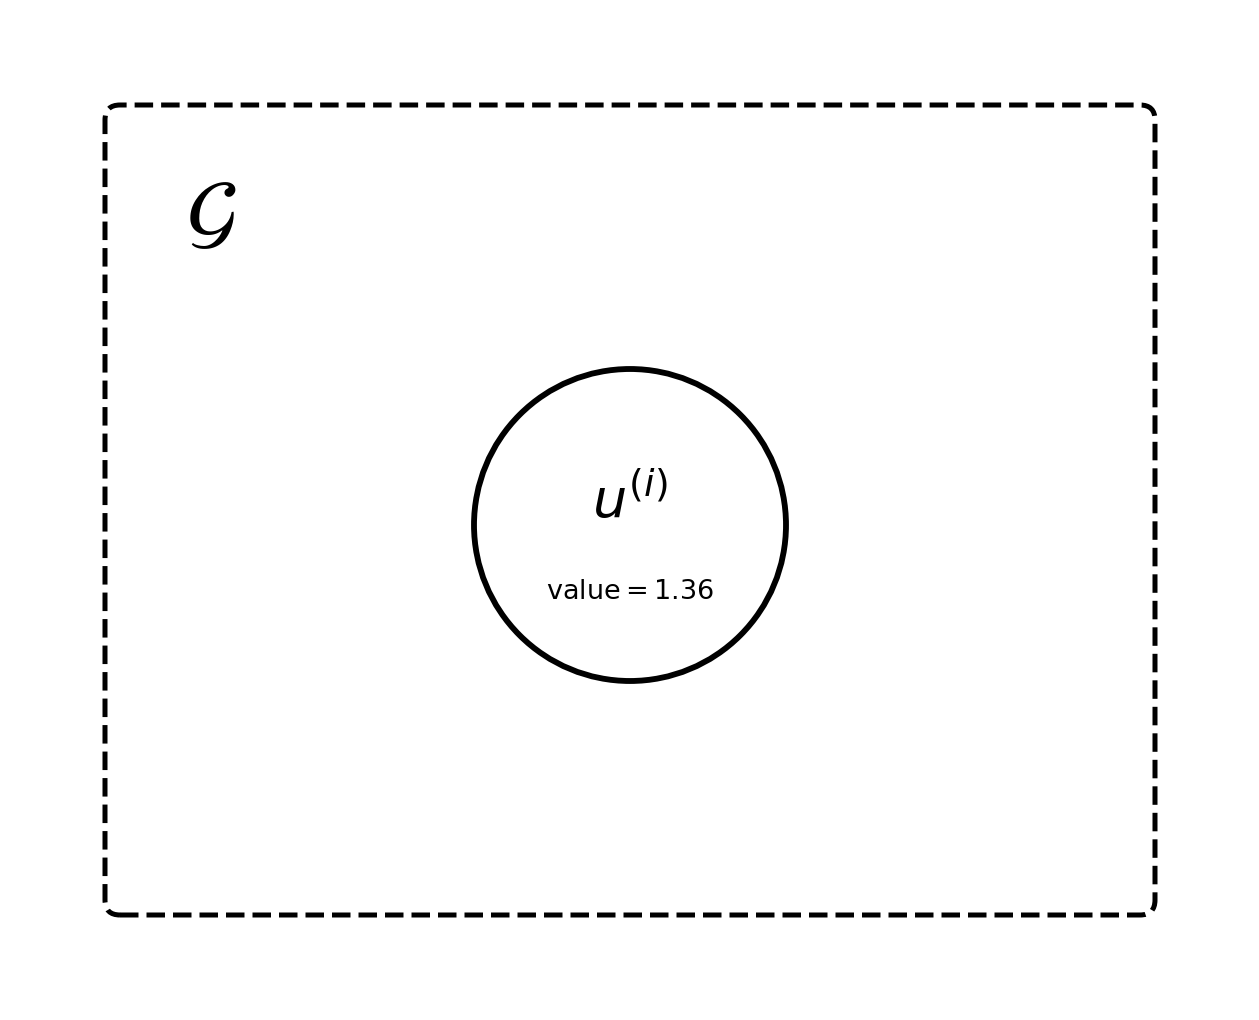

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle

fig, ax = plt.subplots(figsize=(4, 3.2), dpi=300)
ax.set_xlim(0, 4)
ax.set_ylim(0, 3.2)
ax.set_aspect('equal')
ax.axis('off')

# Graph G bounding box (dashed)
graph_box = FancyBboxPatch(
    (0.3, 0.3), 3.4, 2.6,
    boxstyle="round,pad=0.05",
    linewidth=1.2,
    edgecolor='black',
    facecolor='white',
    linestyle='dashed'
)
ax.add_patch(graph_box)

# Label G (top-left of box)
ax.text(0.52, 2.72, r'$\mathcal{G}$', fontsize=20, va='top', ha='left',
        fontfamily='serif', style='italic')

# Node circle
cx, cy, r = 2.0, 1.55, 0.52
node = Circle((cx, cy), r, linewidth=1.4, edgecolor='black', facecolor='white', zorder=3)
ax.add_patch(node)

# Node label u^(i) inside circle
ax.text(cx, cy + 0.08, r'$u^{(i)}$', fontsize=13, ha='center', va='center',
        fontfamily='serif', zorder=4)

# Value label below node label
ax.text(cx, cy - 0.22, r'$\text{value} = 1.36$', fontsize=6.5, ha='center', va='center',
        fontfamily='serif', color='black', zorder=4)

plt.tight_layout(pad=0)
plt.savefig('/Users/leviharris/Desktop/docs/headshots/leharris3.github.io/assets/img/ml-concepts/backprop/cg_single_node.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

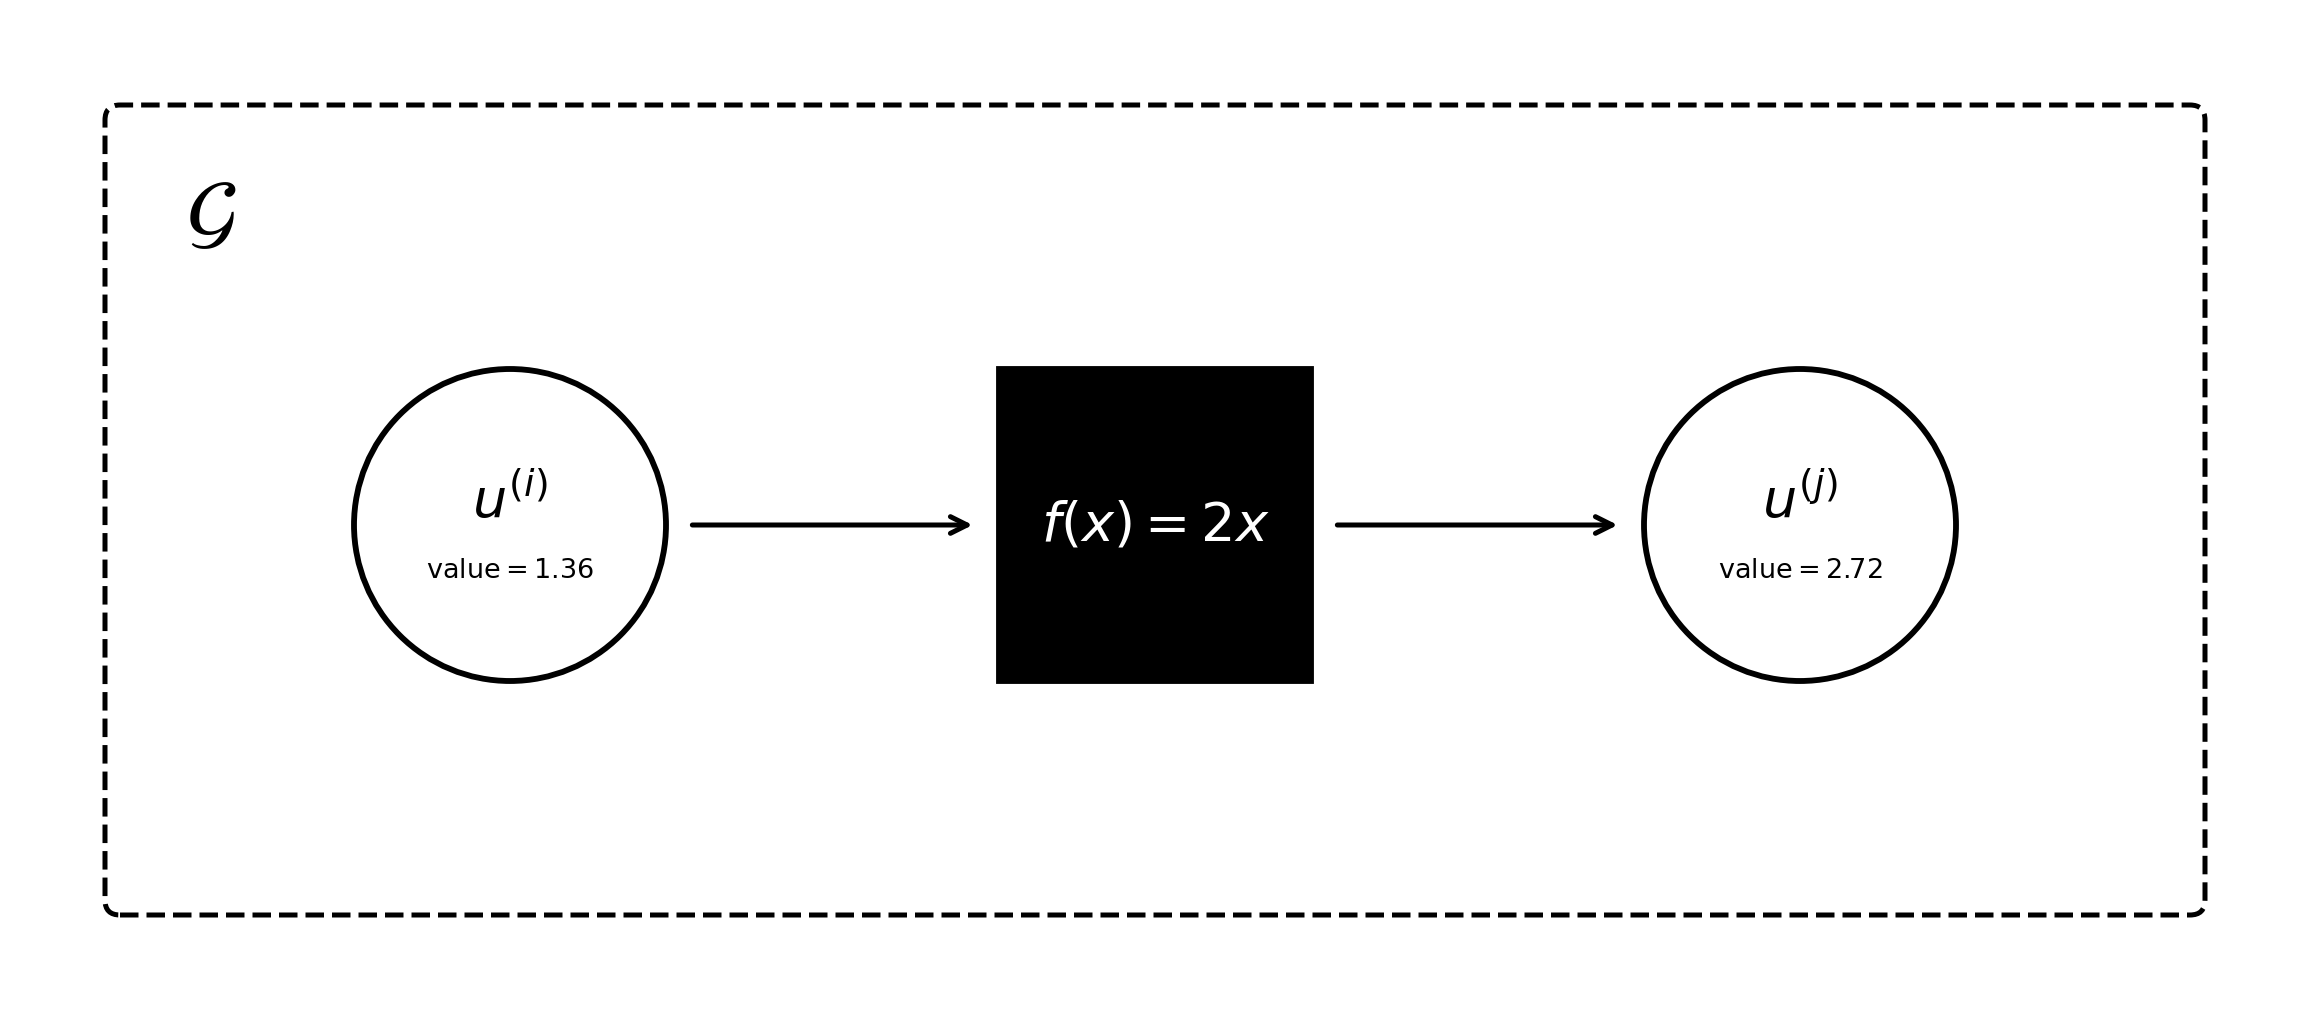

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle

fig, ax = plt.subplots(figsize=(7.5, 3.2), dpi=300)
ax.set_xlim(0, 7.5)
ax.set_ylim(0, 3.2)
ax.set_aspect('equal')
ax.axis('off')

# Graph G bounding box (dashed)
graph_box = FancyBboxPatch(
    (0.3, 0.3), 6.9, 2.6,
    boxstyle="round,pad=0.05",
    linewidth=1.2,
    edgecolor='black',
    facecolor='white',
    linestyle='dashed'
)
ax.add_patch(graph_box)

# Label G (top-left of box)
ax.text(0.52, 2.72, r'$\mathcal{G}$', fontsize=20, va='top', ha='left',
        fontfamily='serif', style='italic')

cy = 1.55
r  = 0.52   # value node radius
hw = 0.52   # op node half-width

# --- value node u^(i) ---
cx_i = 1.6
node_i = Circle((cx_i, cy), r, linewidth=1.4, edgecolor='black', facecolor='white', zorder=3)
ax.add_patch(node_i)
ax.text(cx_i, cy + 0.08, r'$u^{(i)}$', fontsize=13, ha='center', va='center',
        fontfamily='serif', zorder=4)
ax.text(cx_i, cy - 0.15, r'$\text{value} = 1.36$', fontsize=6.5, ha='center', va='center',
        fontfamily='serif', color='black', zorder=4)

# --- arrow u^(i) → f ---
cx_op = 3.75
ax.annotate('', xy=(cx_op - hw - 0.06, cy), xytext=(cx_i + r + 0.06, cy),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

# --- operation node f (black square, white text) ---
op_node = FancyBboxPatch(
    (cx_op - hw, cy - hw), 2*hw, 2*hw,
    boxstyle="square,pad=0.0",
    linewidth=1.4, edgecolor='black', facecolor='black', zorder=3
)
ax.add_patch(op_node)
ax.text(cx_op, cy, r'$f(x) = 2x$', fontsize=13, ha='center', va='center',
        fontfamily='serif', color='white', zorder=4)

# --- arrow f → u^(j) ---
cx_j = 5.9
ax.annotate('', xy=(cx_j - r - 0.06, cy), xytext=(cx_op + hw + 0.06, cy),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

# --- value node u^(j) ---
node_j = Circle((cx_j, cy), r, linewidth=1.4, edgecolor='black', facecolor='white', zorder=3)
ax.add_patch(node_j)
ax.text(cx_j, cy + 0.08, r'$u^{(j)}$', fontsize=13, ha='center', va='center',
        fontfamily='serif', zorder=4)
ax.text(cx_j, cy - 0.15, r'$\text{value} = 2.72$', fontsize=6.5, ha='center', va='center',
        fontfamily='serif', color='black', zorder=4)

plt.tight_layout(pad=0)
plt.savefig('/Users/leviharris/Desktop/docs/headshots/leharris3.github.io/assets/img/ml-concepts/backprop/cg_op_node.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()